### Image

In [ ]:
import pandas as pd

image_prompts = [
    "steaming cup of coffee and a croissant on a table",
    "steaming cup of coffee and toast in a cafe",
    "sunset over a calm ocean",
    "sunset over a tranquil forest",
]
image_responses = [
    {
        "parts": [
            {
                "file_data": {
                    "mime_type": "image/png",
                    "file_uri": "gs://cloud-samples-data/generative-ai/evaluation/images/coffee.png",
                }
            }
        ],
        "role": "model",
    },
    {
        "parts": [
            {
                "file_data": {
                    "mime_type": "image/png",
                    "file_uri": "gs://cloud-samples-data/generative-ai/evaluation/images/coffee.png",
                }
            }
        ],
        "role": "model",
    },
    {
        "parts": [
            {
                "file_data": {
                    "mime_type": "image/png",
                    "file_uri": "gs://cloud-samples-data/generative-ai/evaluation/images/sunset.png",
                }
            }
        ],
        "role": "model",
    },
    {
        "parts": [
            {
                "file_data": {
                    "mime_type": "image/png",
                    "file_uri": "gs://cloud-samples-data/generative-ai/evaluation/images/sunset.png",
                }
            }
        ],
        "role": "model",
    }
]

image_eval_dataset = pd.DataFrame(
    {
        "prompt": image_prompts,
        "response": image_responses,
    }
)

In [2]:
from vertexai import Client, types
import render_util
import google.auth
from google.genai import types as genai_types
httpOptions = genai_types.HttpOptions(
    retry_options=genai_types.HttpRetryOptions(
        attempts=5,           # 최대 재시도 횟수
        initial_delay=1.0,    # 첫 대기 시간
        http_status_codes=[429, 500, 502, 503, 504] # 재시도 대상 에러 코드
    )
)
_, PROJECT_ID = google.auth.default()
LOCATION = "global"
client = Client(project=PROJECT_ID, location=LOCATION)

In [ ]:
image_data_with_rubrics = client.evals.generate_rubrics(
    src=image_eval_dataset,
    rubric_group_name="gecko_image_rubrics",
    predefined_spec_name=types.RubricMetric.GECKO_TEXT2IMAGE,
    config=types.RubricGenerationConfig(http_options=httpOptions)
)

render_util.display_evaluation_dataset(image_data_with_rubrics)

C:\Users\jeehyeok\AppData\Roaming\Python\Python312\site-packages\authlib\_joserfc_helpers.py:8: AuthlibDeprecationWarning: authlib.jose module is deprecated, please use joserfc instead.
It will be compatible before version 2.0.0.
  from authlib.jose import ECKey


In [ ]:
# @title ### Evaluate with rubrics
# @markdown Then we use the generated rubrics to evaluate the quality of the responses.

image_eval_result = client.evals.evaluate(
    dataset=image_data_with_rubrics,
    metrics=[types.RubricMetric.GECKO_TEXT2IMAGE],
    config=types.EvaluateMethodConfig(http_options=httpOptions)
)

render_util.display_evaluation_result(image_eval_result)

Computing Metrics for Evaluation Dataset: 100%|██████████| 4/4 [00:07<00:00,  1.83s/it]


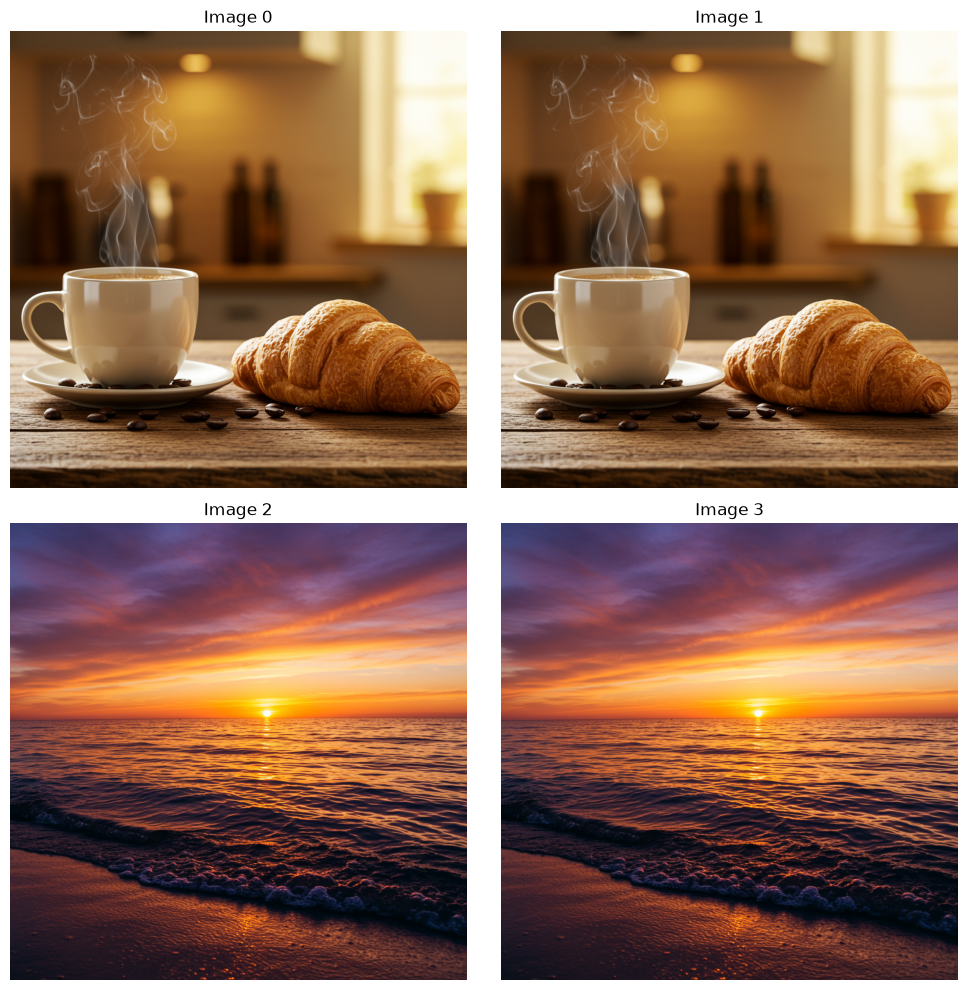

In [ ]:
import io
from google.cloud import storage
import matplotlib.pyplot as plt
from PIL import Image
from urllib.parse import urlparse
# GCS 클라이언트 생성 (GCP Vertex AI Workbench 또는 gcloud 인증이 되어있는 환경 기준)
storage_client = storage.Client()
bucket = storage_client.bucket("cloud-samples-data")

# 이미지 가져오기
images = []
image_paths = [
    urlparse(item["parts"][0]["file_data"]["file_uri"]).path.lstrip("/")
    for item in image_responses
]
for path in image_paths:
    blob = bucket.blob(path)
    # 이미지 데이터를 메모리로 다운로드
    image_bytes = blob.download_as_bytes()
    # PIL Image 객체로 변환
    img = Image.open(io.BytesIO(image_bytes))
    images.append(img)

# --------------------------------------------------
# 2. 2x2 타일 형태(그리드)로 시각화
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 10))  # 2행 2열 타일 배치
axes = axes.flatten()  # 2차원 배열을 1차원으로 펼쳐서 루프 돌기 편하게 변경

for i, img in enumerate(images):
    axes[i].imshow(img)
    axes[i].set_title(f"Image {i}")
    axes[i].axis("off")  # 눈금 및 축 숨기기

plt.tight_layout()
plt.show()

### Video

In [9]:
import pandas as pd

video_prompts = [
    "Snow blanketed rocky mountains surround and shadow deep canyons. the canyons bend through the high elevated mountain peaks. black and white",
    "Lush green valley is carved between rocky cliffs. the valley winds through the high elevated rock faces. misty morning",
    "A couple in formal evening wear going home get caught in a heavy downpour with umbrellas",
    "Two friends, dressed in casual summer clothes, are caught in a light summer rain while running home",
]
video_responses = [
    {
        "parts": [
            {
                "file_data": {
                    "mime_type": "video/mp4",
                    "file_uri": "gs://cloud-samples-data/generative-ai/evaluation/videos/mountain.mp4",
                }
            }
        ],
        "role": "model",
    },
    {
        "parts": [
            {
                "file_data": {
                    "mime_type": "video/mp4",
                    "file_uri": "gs://cloud-samples-data/generative-ai/evaluation/videos/mountain.mp4",
                }
            }
        ],
        "role": "model",
    },
    {
        "parts": [
            {
                "file_data": {
                    "mime_type": "video/mp4",
                    "file_uri": "gs://cloud-samples-data/generative-ai/evaluation/videos/couple.mp4",
                }
            }
        ],
        "role": "model",
    },
    {
        "parts": [
            {
                "file_data": {
                    "mime_type": "video/mp4",
                    "file_uri": "gs://cloud-samples-data/generative-ai/evaluation/videos/couple.mp4",
                }
            }
        ],
        "role": "model",
    },
]

video_eval_dataset = pd.DataFrame(
    {
        "prompt": video_prompts,
        "response": video_responses,
    }
)

In [10]:
video_data_with_rubrics = client.evals.generate_rubrics(
    src=video_eval_dataset,
    rubric_group_name="gecko_video_rubrics",
    predefined_spec_name=types.RubricMetric.GECKO_TEXT2VIDEO,
    config=types.RubricGenerationConfig(http_options=httpOptions)
)

render_util.display_evaluation_dataset(video_data_with_rubrics)

In [11]:
eval_result = client.evals.evaluate(
    dataset=video_data_with_rubrics,
    metrics=[types.RubricMetric.GECKO_TEXT2VIDEO],
    config=types.EvaluateMethodConfig(http_options=httpOptions)
)

render_util.display_evaluation_result(eval_result)

Computing Metrics for Evaluation Dataset: 100%|██████████| 4/4 [00:18<00:00,  4.74s/it]


In [19]:
# 비디오 가져오기
import os
from IPython.display import HTML, display
os.makedirs("./temp_videos", exist_ok=True)
local_video_paths = []
video_paths = [
    urlparse(item["parts"][0]["file_data"]["file_uri"]).path.lstrip("/")
    for item in video_responses
]
for i, path in enumerate(video_paths):
    blob = bucket.blob(path)
    # 로컬 파일로 다운로드
    local_path = f"./temp_videos/video_{i}.mp4"
    blob.download_to_filename(local_path)
    local_video_paths.append(local_path)

# --------------------------------------------------
# 2. 2x2 타일 형태(그리드)로 시각화
# --------------------------------------------------
html_items = ""
for i, path in enumerate(local_video_paths):
    html_items += f"""
    <div style="text-align: center;">
        <p style="font-weight: bold; margin-bottom: 5px;">Video {i}</p>
        <video width="100%" controls muted loop src="{path}"></video>
    </div>
    """

html_code = f"""
<div style="display: grid; grid-template-columns: repeat(2, 1fr); gap: 15px; width: 100%; max-width: 800px;">
    {html_items}
</div>
"""

# 6. 주피터 노트북에 비디오 타일 출력
display(HTML(html_code))